# Figure 4- Viol Stim Interactions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.data import ANIMAL_IDS
from violmulti.features.exp_filter import ExpFilter
from violmulti.features.design_matrix_generator_PWM import *
from scipy.stats import shapiro, ttest_rel, wilcoxon

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

prev_viol_binary_itrx_exp = save_name = "2025_04_14_fig4_fit_binary_prev_viol_stim_intrx_n_rs47.pkl"

prev_viol_filtered_itrx_exp = "2025_04_17_fig4_fit_filtered_prev_viol_stim_intrx_n_rs47.pkl"

compare_exp = "2025_04_16_fig4_compare_intrxs_rs47.pkl"

In [2]:
tdf = DatasetLoader(data_type="new_trained_cleaned").load_data()

DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


In [42]:
def within_subject_test(
    df: pd.DataFrame,
    subject_col: str,
    condition_col: str,
    value_col: str,
    condition_labels: dict | None = None
) -> dict:
    """
    df              : long-form DataFrame
    subject_col     : column identifying each subject/replicate
    condition_col   : column with exactly two unique conditions
    value_col       : measurement variable
    condition_labels: optional mapping {orig_label: pretty_name}
    """
    # 1) pivot wide
    wide = df.pivot(index=subject_col, columns=condition_col, values=value_col)
    # optionally rename columns
    if condition_labels:
        wide = wide.rename(columns=condition_labels)
    conds = list(wide.columns)
    a, b = conds

    # 2) descriptives
    m_a, s_a = wide[a].mean(), wide[a].std()
    m_b, s_b = wide[b].mean(), wide[b].std()
    n = len(wide)
    print(f"{n} subjects/replicates:")
    print(f" • {a}: mean = {m_a:.3f}, SD = {s_a:.3f}")
    print(f" • {b}: mean = {m_b:.3f}, SD = {s_b:.3f}")

    # 3) paired differences
    diff = wide[b] - wide[a]

    # 4) normality check
    W, p_norm = shapiro(diff)
    print(f"\nShapiro–Wilk: W = {W:.3f}, p = {p_norm:.3f}")

    # 5) choose test
    if p_norm > 0.05:
        t_stat, p_val = ttest_rel(wide[b], wide[a])
        print(f"Paired t-test: t = {t_stat}, p = {p_val}")
        return {"test": "ttest", "stat": t_stat, "p": p_val}
    else:
        W2, p2 = wilcoxon(wide[b], wide[a])
        print(f"Wilcoxon signed-rank: W = {W2}, p = {p2}")
        return {"test": "wilcoxon", "stat": W2, "p": p2}

# A post violation hit rate


In [4]:
# add prev violation to tdf
tdf["prev_violation"] = prev_violation(tdf)
print(len(tdf.groupby(["animal_id", "session"])))
# compute hit rates by violation history
hit_rates_by_viol_hist = tdf.groupby(["animal_id", "session", "prev_violation"])["hit"].mean().reset_index().groupby(["animal_id", "prev_violation"]).hit.mean().reset_index()
hit_rates_by_viol_hist["percent_correct"] =hit_rates_by_viol_hist.hit * 100

hit_rates_by_viol_hist.to_csv(
DATA_PATH + "/hit_rates_by_viol_hist_long.csv", index=False
)
hit_rates_by_viol_hist.head()

5210


,animal_id,prev_violation,hit,percent_correct
0,W051,0,0.802936,80.293573
1,W051,1,0.766545,76.654478
2,W060,0,0.830631,83.063119
3,W060,1,0.783092,78.309221
4,W065,0,0.776971,77.697107


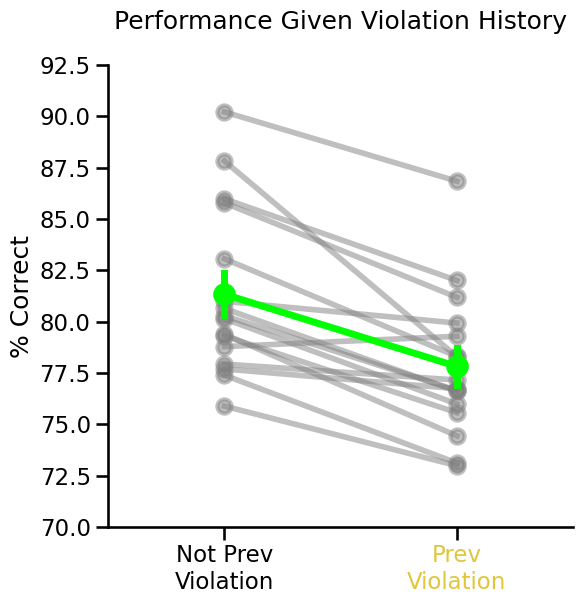

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))

sns.despine()

hit_rates_by_viol_hist["percent_correct"] =hit_rates_by_viol_hist.hit * 100
sns.pointplot(data=hit_rates_by_viol_hist, x="prev_violation", y="percent_correct", hue="animal_id", ax=ax, palette=["gray"] * 16, alpha=0.5)

sns.pointplot(data=hit_rates_by_viol_hist, x="prev_violation", y="percent_correct", ax=ax, color=c.HIT_COLOR, errorbar="se", lw=5)

ax.get_legend().remove()

ax.set_xticks(range(2))
# Set the tick labels
ax.set_xticklabels(["Not Prev\nViolation", "Prev\nViolation"])

# Get the tick labels
tick_labels = ax.get_xticklabels()

# Set the colors for each label
colors = ["k", c.VIOLATION_COLOR]
for label, color in zip(tick_labels, colors):
    label.set_color(color)

ax.set(ylim=(70, 92.5), ylabel=("% Correct"), xlabel="")
ax.set_title("Performance Given Violation History\n")

plt.savefig("figures/fig4_hit_rate_point_plot.png", dpi=300, bbox_inches="tight")

### Stats


In [32]:
# load & prepare
hit_df = pd.read_csv("data/hit_rates_by_viol_hist_long.csv")
hit_df["prev_violation"] = hit_df["prev_violation"].astype(int)

# run
hit_stats = within_subject_test(
    hit_df,
    subject_col="animal_id",
    condition_col="prev_violation",
    value_col="hit",
    condition_labels={0: "Not Prev Violation", 1: "Prev Violation"}
)

16 subjects/replicates:
 • Not Prev Violation: mean = 0.813, SD = 0.041
 • Prev Violation: mean = 0.778, SD = 0.035

Shapiro–Wilk: W = 0.891, p = 0.057
Paired t-test: t = -6.120733149022935, p = 1.9579579186724175e-05


# B weights


In [51]:
ddf = pd.read_csv("data/demo_intuition_data.csv")

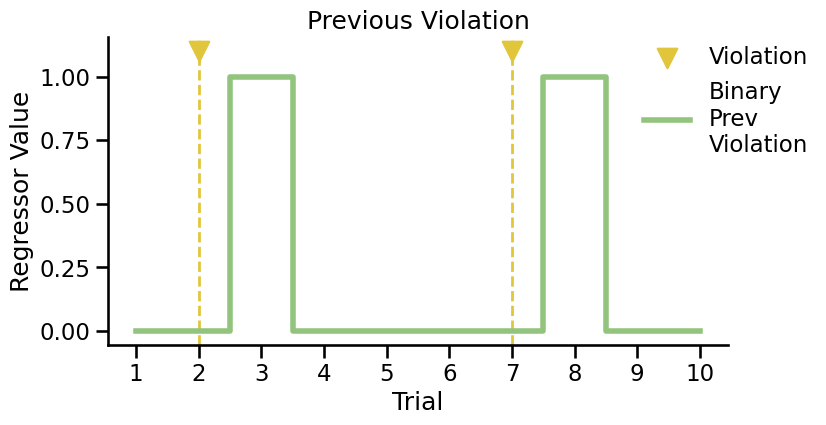

In [84]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev\nViolation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4)

ax.legend(bbox_to_anchor=(.85, 1), loc='upper left', borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Previous Violation",
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig4b_prev_viol_weights_intuition.png", dpi=300, bbox_inches="tight")

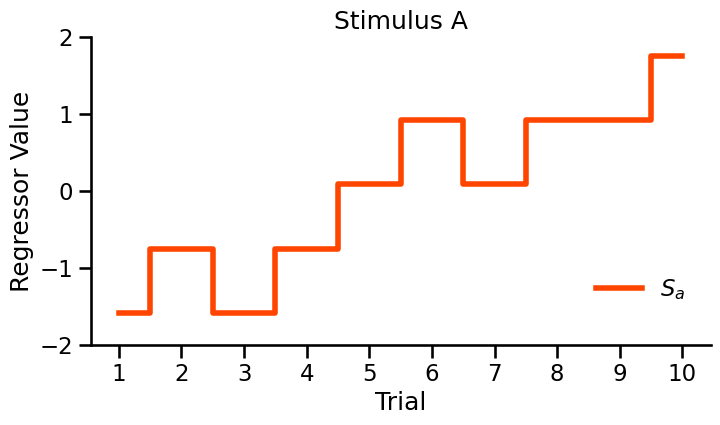

In [53]:
fig, ax = plt.subplots(figsize=(8, 4)) 


sns.lineplot(x=ddf["trial"], y=ddf["s_a"], drawstyle='steps-mid', label="$S_a$", ax=ax, color="orangered", linewidth=4)

ax.legend(bbox_to_anchor=(.8, 0.25), loc='upper left', borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Stimulus A",
    ylim=(-2,2)
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig4b_Stimulus_A_weights_intuition.png", dpi=300, bbox_inches="tight")

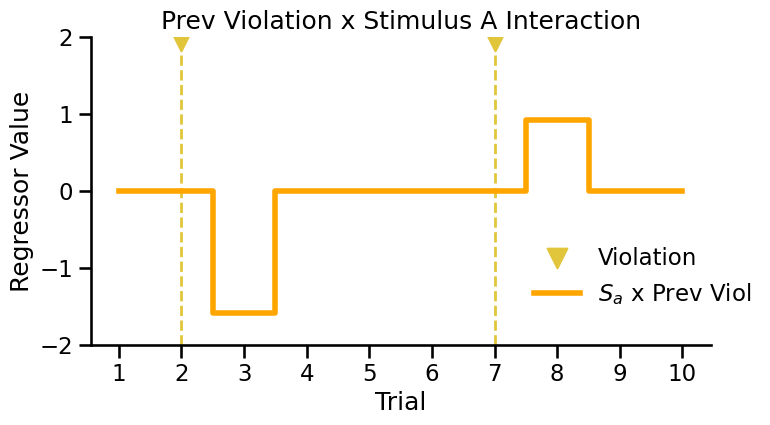

In [54]:
fig, ax = plt.subplots(figsize=(8, 4)) 


vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.95), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["s_a_x_prev_violation"], drawstyle='steps-mid', label="$S_a$ x Prev Viol", ax=ax, color="orange", linewidth=4)

ax.legend(bbox_to_anchor=(.7, 0.35), borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Prev Violation x Stimulus A Interaction",
    ylim=(-2,2)
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig4b_interaction_intuition.png", dpi=300, bbox_inches="tight")

## ii


In [55]:
mvpv = ModelVisualizer(load_experiment(prev_viol_binary_itrx_exp))
XMIN=-2.1
XMAX=2.1

In [56]:
ORDER = [
    "s_a", 
    "sa_x_prev_viol", 
    "s_b", 
    "sb_x_prev_viol",
    "prev_violation",
]
# Get the DataFrame
df = mvpv.unpack_features_and_weights().query("feature in @ORDER")

# If you want to reorder the features according to ORDER
df['feature'] = pd.Categorical(df['feature'], categories=ORDER, ordered=True)


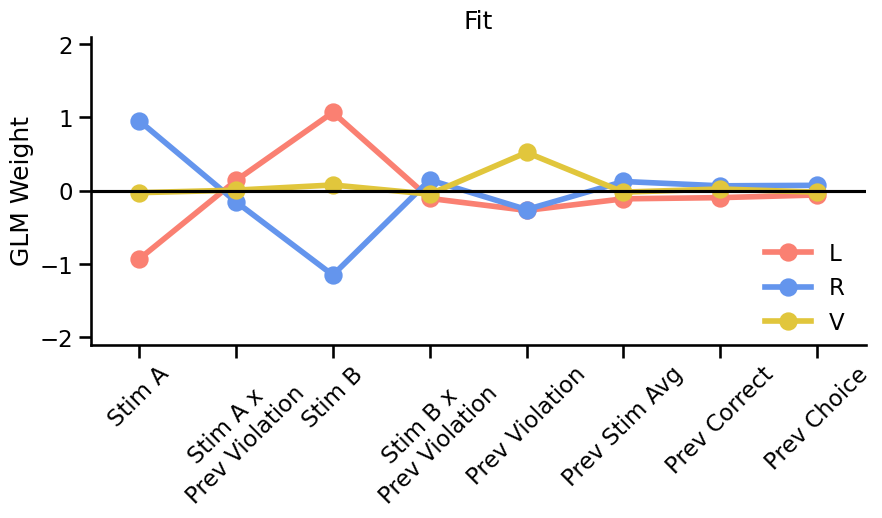

In [57]:
fig, ax = plt.subplots(figsize=(10, 4)) 

mvpv.plot_weights_summary(ax=ax,style="point", plot_bias = False, title="Fit", plot_individuals=False, seed=19, palette=c.MULTI_CHOICE_PAL, errorbar=None)

ax.legend(bbox_to_anchor=(1, 0.4), frameon=False)

LABELS = [
    "Stim A", 
    "Stim A x\nPrev Violation",
    "Stim B", 
    "Stim B x\nPrev Violation",
    "Prev Violation", 
    "Prev Stim Avg", 
    "Prev Correct", 
    "Prev Choice",
]

# set y labels
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS)

ax.set_ylim(XMIN, XMAX)

plt.savefig("figures/fig4b_prev_viol_intrx_point.png", dpi=300, bbox_inches="tight")

## iii


In [58]:
mvpv = ModelVisualizer(load_experiment(prev_viol_filtered_itrx_exp))
XMIN=-2.1
XMAX=2.1

In [59]:
ORDER = [
    "s_a", 
    "sa_x_prev_viol", 
    "s_b", 
    "sb_x_prev_viol",
    "filt_prev_violation",
]
# Get the DataFrame
df = mvpv.unpack_features_and_weights().query("feature in @ORDER")


# If you want to reorder the features according to ORDER
df['feature'] = pd.Categorical(df['feature'], categories=ORDER, ordered=True)


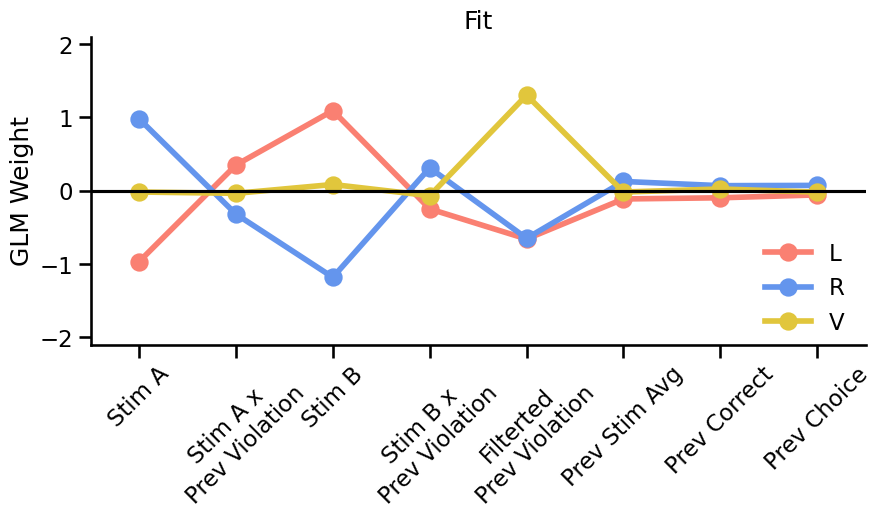

In [62]:
fig, ax = plt.subplots(figsize=(10, 4)) 

mvpv.plot_weights_summary(ax=ax,style="point", plot_bias = False, title="Fit", plot_individuals=False, seed=19, palette=c.MULTI_CHOICE_PAL, errorbar=None)

ax.legend(bbox_to_anchor=(1, 0.4), frameon=False)

LABELS = [
    "Stim A", 
    "Stim A x\nPrev Violation",
    "Stim B", 
    "Stim B x\nPrev Violation",
    "Filterted\nPrev Violation", 
    "Prev Stim Avg", 
    "Prev Correct", 
    "Prev Choice",
]

# set y labels
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS)

ax.set_ylim(XMIN, XMAX)

plt.savefig("figures/fig4c_filt_prev_viol_intrx_point.png", dpi=300, bbox_inches="tight")

# C psychometric


In [33]:
from violmulti.utils.simulate_prev_viol_pyschometrics import SimulatePrevViolPyschometric


In [34]:
experiment = load_experiment(save_name)  
model_name = "prev_viol_binary_itrx"

In [35]:
sim_psych = SimulatePrevViolPyschometric(experiment, model_name)
PAL = ["gray", c.VIOLATION_COLOR]
STYLE_ORDER = [1, 0]


In [47]:
sim_psych

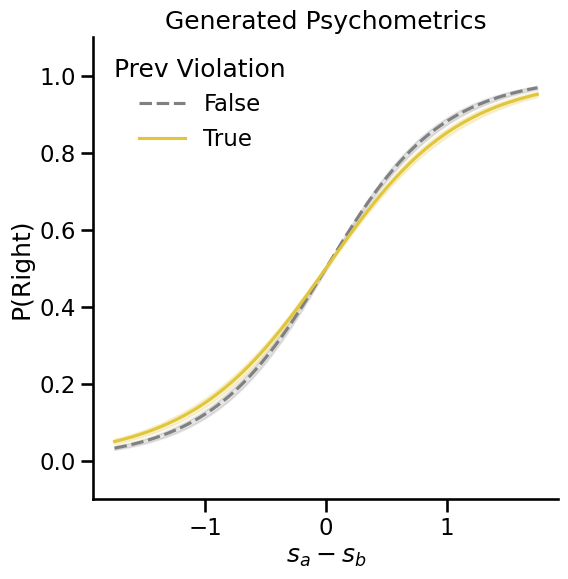

In [36]:
fig, ax = sim_psych.plot_summary(delta_range=(-1.75,1.75), title="Generated Psychometrics", palette=PAL, style_order=STYLE_ORDER)

fig.savefig("figures/fig4_psych_simulation.png", bbox_inches="tight", dpi=300)



In [37]:
results = sim_psych.extract_slope_and_lapse()
results["combined_lapse"] = results["upper_lapse"] + results["lower_lapse"]

# add a replicate index so we can pivot
results = results.reset_index().rename(columns={"index":"replicate"})

# melt
results_melted = (
    pd.melt(
        results,
        id_vars=["replicate","v_x"],
        value_vars=["slope","combined_lapse","upper_lapse","lower_lapse"],
        var_name="metric",
        value_name="value"
    )
    .rename(columns={"v_x":"prev_violation"})
)

In [48]:
# 1) extract
results = sim_psych.extract_slope_and_lapse()
results["combined_lapse"] = results["upper_lapse"] + results["lower_lapse"]

# 2) melt (with animal_id!)
results_melted = pd.melt(
    results,
    id_vars=["animal_id", "v_x"],
    value_vars=["slope", "combined_lapse"],
    var_name="metric",
    value_name="value"
).rename(columns={"v_x": "prev_violation"})


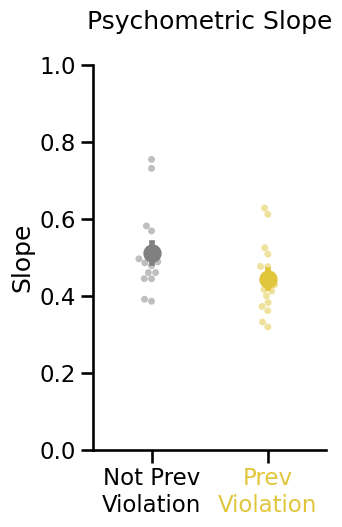

In [49]:
fig, ax = plt.subplots(figsize=(3, 5))
plot_df = results_melted.query("metric == 'slope'").copy()
plot_df["prev_violation"] = plot_df["prev_violation"].map({0: "False", 1: "True"})



sns.pointplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, linestyle=None, errorbar="se")
sns.swarmplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, alpha=0.5)

ax.set_xticks(range(2))
ax.set_xticklabels(["Not Prev\nViolation", "Prev\nViolation"])
tick_labels = ax.get_xticklabels()

# Set the colors for each label
colors = ["k", c.VIOLATION_COLOR]
for label, color in zip(tick_labels, colors):
    label.set_color(color)

sns.despine()
ax.set_title("Psychometric Slope\n")
_ =ax.set(ylabel="Slope", xlabel="")
ax.set_ylim(0, 1)
plt.savefig("figures/fig4_psych_slope.png", dpi=300, bbox_inches="tight")

### Slope Stats


In [50]:
slope_stats = within_subject_test(
    results_melted.query("metric=='slope'"),
    subject_col="animal_id",
    condition_col="prev_violation",
    value_col="value",
    condition_labels={0: "Not Prev Violation", 1: "Prev Violation"}
)


16 subjects/replicates:
 • Not Prev Violation: mean = 0.512, SD = 0.104
 • Prev Violation: mean = 0.445, SD = 0.090

Shapiro–Wilk: W = 0.951, p = 0.510
Paired t-test: t = -5.5571905951667535, p = 5.4860600715006316e-05


## Lapses


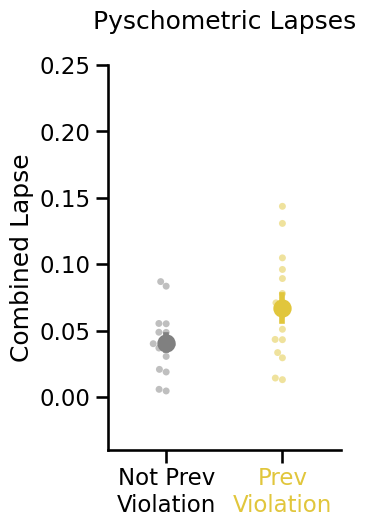

In [79]:
fig, ax = plt.subplots(figsize=(3, 5))
plot_df = results_melted.query("metric == 'combined_lapse'").copy()
plot_df["prev_violation"] = plot_df["prev_violation"].map({0: "False", 1: "True"})


sns.pointplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, linestyle=None, errorbar="se")
sns.swarmplot(data=plot_df, x="prev_violation", y="value", hue="prev_violation", palette=PAL, ax=ax, alpha=0.5)


ax.set_xticks(range(2))
ax.set_xticklabels(["Not Prev\nViolation", "Prev\nViolation"])
tick_labels = ax.get_xticklabels()

# Set the colors for each label
colors = ["k", c.VIOLATION_COLOR]
for label, color in zip(tick_labels, colors):
    label.set_color(color)
sns.despine()
ax.set_title("Pyschometric Lapses\n")
_ =ax.set(ylabel="Combined Lapse", xlabel="")
ax.set_ylim(-.04, 0.25)

plt.savefig("figures/fig4_psych_lapses.png", dpi=300, bbox_inches="tight")

### Stats


In [51]:
lapse_stats = within_subject_test(
    results_melted.query("metric=='combined_lapse'"),
    subject_col="animal_id",
    condition_col="prev_violation",
    value_col="value",
    condition_labels={0: "Not Prev Violation", 1: "Prev Violation"}
)

16 subjects/replicates:
 • Not Prev Violation: mean = 0.041, SD = 0.023
 • Prev Violation: mean = 0.067, SD = 0.039

Shapiro–Wilk: W = 0.939, p = 0.336
Paired t-test: t = 4.6025649104542135, p = 0.00034522203006199695


# Extras


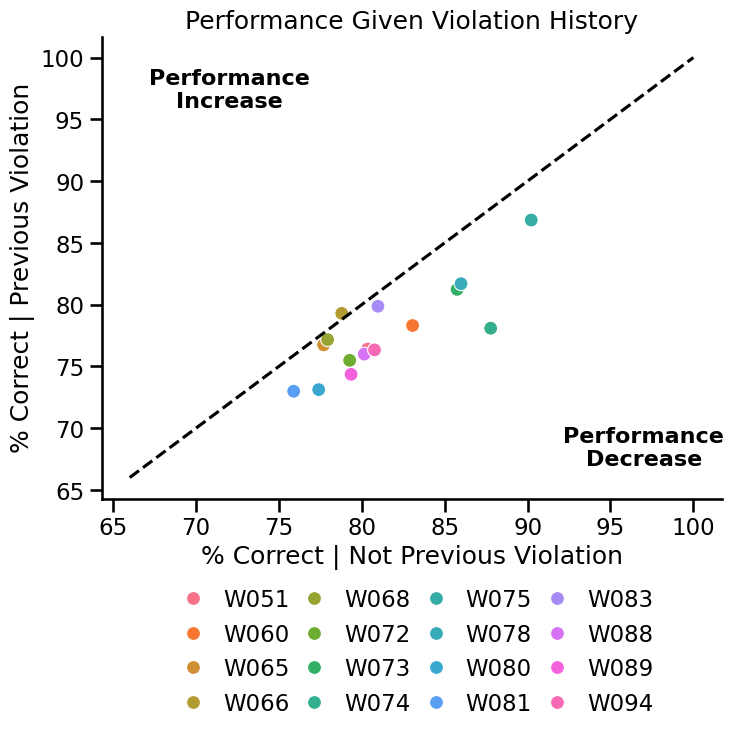

In [49]:


# pivot hit rates by violation history
wide_hit_rates = hit_rates_by_viol_hist.pivot(
    index="animal_id", columns="prev_violation", values="hit"
)
wide_hit_rates.columns = ["hit_rate_wo_prev_viol", "hit_rate_w_prev_viol"]

# multiply by 100
wide_hit_rates = wide_hit_rates * 100
wide_hit_rates.reset_index(inplace=True)

# save hit rates by violation history
wide_hit_rates.to_csv(
    "data/hit_rates_by_viol_hist_wide.csv", index=False
)

limits = (66, 100)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=wide_hit_rates, x="hit_rate_wo_prev_viol", y="hit_rate_w_prev_viol", s=100, hue="animal_id", ax=ax)

ax.plot(limits, limits, "k--")

ax.set_xlabel("% Correct | Not Previous Violation")
ax.set_ylabel("% Correct | Previous Violation")
ax.set_title("Performance Given Violation History")

ax.text(97, 67, "Performance\nDecrease", fontsize=16, fontweight="bold", ha="center")
ax.text(72, 96, "Performance\nIncrease", fontsize=16, fontweight="bold", ha="center")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    handletextpad=0.3,   # smaller = closer label to marker
    columnspacing=0.1    # smaller = less space between items
)

sns.despine()

plt.savefig("figures/fig4_hit_rates_by_viol_hist.png", dpi=300, bbox_inches="tight")